# TP4 — Modèle de Churn (Lumina & Co)

Notebook complet pour le **TP4** : définition du churn, feature engineering, entraînement de modèles, évaluation (AUC/PR, matrice de confusion), interprétation et recommandations.

## Prérequis
- Fichier **transactions_clean.csv** (issu du TP1/TP2) avec au minimum :
  `customer_id, invoice_id, invoice_date, product_code, country, quantity, unit_price`.
- La colonne `line_total` sera recalculée si absente.

> ⚠️ Anti data leakage : la target churn est définie à partir d’un **snapshot_date** (fin dataset). Les features sont calculées sur un historique (fenêtre observation).

## 0) Setup & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
pd.set_option("display.max_columns", 250)

DATA_PATH = "transactions_clean.csv"  # adapte si besoin
assert Path(DATA_PATH).exists(), f"Fichier introuvable: {DATA_PATH}. Mets le bon chemin dans DATA_PATH."

df = pd.read_csv(DATA_PATH)
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["customer_id"] = df["customer_id"].astype(str)
df["invoice_id"] = df["invoice_id"].astype(str)

if "line_total" not in df.columns:
    df["line_total"] = df["quantity"] * df["unit_price"]

df = df.dropna(subset=["customer_id","invoice_id","invoice_date","line_total"])

print("Lignes:", len(df))
print("Clients:", df["customer_id"].nunique())
print("Invoices:", df["invoice_id"].nunique())
df.head()

Lignes: 1346758
Clients: 48866
Invoices: 218671


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,line_total
0,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,13.20
1,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,14.75
2,702453,33347.0,22135,CURIOUS IMAGES GIFT WRAP SET,60.0,0.65,2011-01-02 12:20:00,United Kingdom,39.00
3,554808,17059.0,21166,COOK WITH WINE METAL SIGN,1.0,2.08,2011-05-26 13:01:00,United Kingdom,2.08
4,490817,15311.0,35004S,SET OF 3 SILVER FLYING DUCKS,12.0,1.95,2009-12-08 12:33:00,United Kingdom,23.40


---
## Étape 1 — Définition du churn

### 1.1 Délais inter-achats

In [2]:
df = df.sort_values(["customer_id","invoice_date"]).copy()

df["prev_purchase"] = df.groupby("customer_id")["invoice_date"].shift(1)
df["interpurchase_days"] = (df["invoice_date"] - df["prev_purchase"]).dt.days

interpurchase = df["interpurchase_days"].dropna()

print("Interpurchase mean:", round(interpurchase.mean(),2))
print("Interpurchase median:", round(interpurchase.median(),2))
print("Interpurchase percentiles:")
print(interpurchase.quantile([0.5,0.75,0.9,0.95,0.99]))

Interpurchase mean: 7.72
Interpurchase median: 0.0
Interpurchase percentiles:
0.50      0.0
0.75      0.0
0.90      8.0
0.95     46.0
0.99    182.0
Name: interpurchase_days, dtype: float64


### 1.2 Visualisation distribution + log

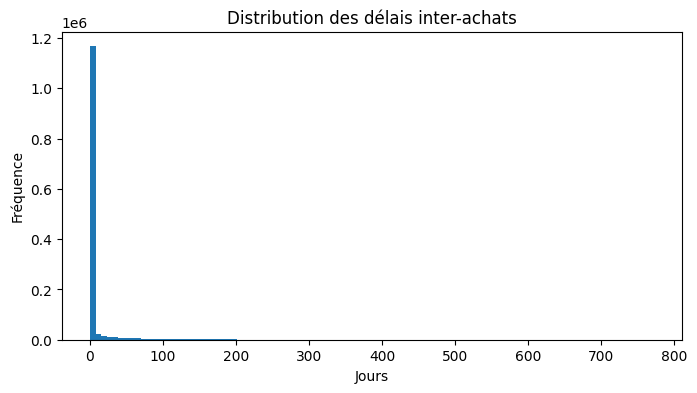

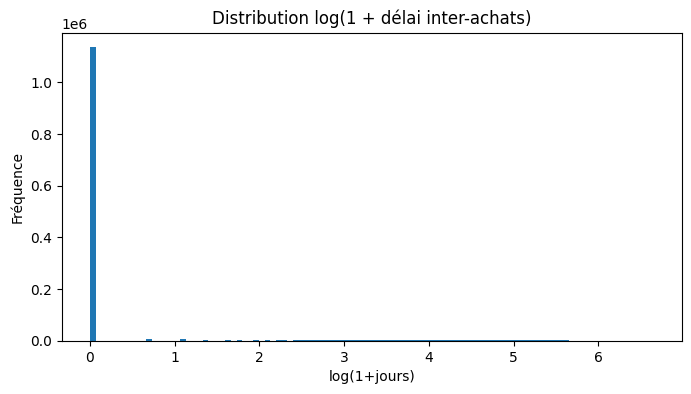

In [3]:
plt.figure(figsize=(8,4))
plt.hist(interpurchase, bins=100)
plt.title("Distribution des délais inter-achats")
plt.xlabel("Jours"); plt.ylabel("Fréquence")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(np.log1p(interpurchase), bins=100)
plt.title("Distribution log(1 + délai inter-achats)")
plt.xlabel("log(1+jours)"); plt.ylabel("Fréquence")
plt.show()

### 1.3 Seuil churn + labellisation

In [4]:
CHURN_THRESHOLD = 90  # à ajuster

snapshot_date = df["invoice_date"].max()

last_purchase = df.groupby("customer_id")["invoice_date"].max()
recency_days = (snapshot_date - last_purchase).dt.days

churn_df = pd.DataFrame({
    "recency_days": recency_days,
    "churn": (recency_days > CHURN_THRESHOLD).astype(int)
})

print("Snapshot date:", snapshot_date)
print("Seuil churn (jours):", CHURN_THRESHOLD)
print("Taux churn:", round(churn_df["churn"].mean()*100, 2), "%")

churn_df.head()

Snapshot date: 2011-12-09 12:50:00
Seuil churn (jours): 90
Taux churn: 74.25 %


,recency_days,churn
customer_id,,
12346.0,325,1
12347.0,1,0
12348.0,74,0
12349.0,18,0
12350.0,309,1


---
## Étape 2 — Feature engineering (anti leakage)

### 2.1 Fenêtre d'observation (12 mois avant snapshot)

In [5]:
OBS_MONTHS = 12

obs_start = snapshot_date - pd.DateOffset(months=OBS_MONTHS)
df_obs = df[(df["invoice_date"] >= obs_start) & (df["invoice_date"] <= snapshot_date)].copy()

print("Observation window:", obs_start, "→", snapshot_date)
print("Transactions obs:", len(df_obs))
print("Clients obs:", df_obs["customer_id"].nunique())

Observation window: 2010-12-09 12:50:00 → 2011-12-09 12:50:00
Transactions obs: 636469
Clients obs: 28418


### 2.2 RFM + tenure + avg_basket

In [6]:
snapshot = snapshot_date + pd.Timedelta(days=1)

feat = df_obs.groupby("customer_id").agg(
    last_purchase=("invoice_date","max"),
    first_purchase=("invoice_date","min"),
    frequency=("invoice_id","nunique"),
    monetary=("line_total","sum"),
)

feat["recency"] = (snapshot - feat["last_purchase"]).dt.days
feat["tenure_days"] = (snapshot - feat["first_purchase"]).dt.days
feat["avg_basket"] = feat["monetary"] / feat["frequency"]

feat = feat.drop(columns=["last_purchase","first_purchase"])
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket
customer_id,,,,,
12346.0,1,77183.60,326,326,77183.600000
12347.0,6,3598.21,2,317,599.701667
12348.0,4,1670.04,75,358,417.510000
12349.0,1,1757.55,19,19,1757.550000
12350.0,1,334.40,310,310,334.400000


### 2.3 Diversité & activité

In [7]:
df_obs["year_month"] = df_obs["invoice_date"].dt.to_period("M")

feat["n_active_months"] = df_obs.groupby("customer_id")["year_month"].nunique()
feat["n_distinct_products"] = df_obs.groupby("customer_id")["product_code"].nunique()

avg_items = (
    df_obs.groupby(["customer_id","invoice_id"])
    .size()
    .groupby("customer_id")
    .mean()
)
feat["avg_items_per_order"] = avg_items
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_active_months,n_distinct_products,avg_items_per_order
customer_id,,,,,,,,
12346.0,1,77183.60,326,326,77183.600000,1,1,1.000000
12347.0,6,3598.21,2,317,599.701667,6,87,25.166667
12348.0,4,1670.04,75,358,417.510000,4,22,6.750000
12349.0,1,1757.55,19,19,1757.550000,1,73,73.000000
12350.0,1,334.40,310,310,334.400000,1,17,17.000000


### 2.4 Régularité inter-achats (std)

In [8]:
def interpurchase_std(dates: pd.Series):
    dates = dates.sort_values()
    diffs = dates.diff().dt.days.dropna()
    if len(diffs) == 0:
        return 0.0
    return float(diffs.std())

feat["std_interpurchase"] = df_obs.groupby("customer_id")["invoice_date"].apply(interpurchase_std)
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_active_months,n_distinct_products,avg_items_per_order,std_interpurchase
customer_id,,,,,,,,,
12346.0,1,77183.60,326,326,77183.600000,1,1,1.000000,0.000000
12347.0,6,3598.21,2,317,599.701667,6,87,25.166667,11.727863
12348.0,4,1670.04,75,358,417.510000,4,22,6.750000,36.491854
12349.0,1,1757.55,19,19,1757.550000,1,73,73.000000,0.000000
12350.0,1,334.40,310,310,334.400000,1,17,17.000000,0.000000


### 2.5 Tendance CA mensuel (slope)

In [9]:
from sklearn.linear_model import LinearRegression

def spending_trend(customer_df: pd.DataFrame):
    monthly = (customer_df.set_index("invoice_date")
               .resample("ME")["line_total"].sum().reset_index())
    if len(monthly) < 2:
        return 0.0
    X = np.arange(len(monthly)).reshape(-1,1)
    y = monthly["line_total"].values
    model = LinearRegression()
    model.fit(X, y)
    return float(model.coef_[0])

feat["spending_trend"] = df_obs.groupby("customer_id").apply(spending_trend)
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_active_months,n_distinct_products,avg_items_per_order,std_interpurchase,spending_trend
customer_id,,,,,,,,,,
12346.0,1,77183.60,326,326,77183.600000,1,1,1.000000,0.000000,0.000000
12347.0,6,3598.21,2,317,599.701667,6,87,25.166667,11.727863,15.716538
12348.0,4,1670.04,75,358,417.510000,4,22,6.750000,36.491854,-36.724121
12349.0,1,1757.55,19,19,1757.550000,1,73,73.000000,0.000000,0.000000
12350.0,1,334.40,310,310,334.400000,1,17,17.000000,0.000000,0.000000


### 2.6 Saison (peak_ratio) + pays dominant

In [10]:
peak_months = [11,12]

df_obs["is_peak"] = df_obs["invoice_date"].dt.month.isin(peak_months)
feat["peak_ratio"] = df_obs.groupby("customer_id")["is_peak"].mean()

feat["country"] = df_obs.groupby("customer_id")["country"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_active_months,n_distinct_products,avg_items_per_order,std_interpurchase,spending_trend,peak_ratio,country
customer_id,,,,,,,,,,,,
12346.0,1,77183.60,326,326,77183.600000,1,1,1.000000,0.000000,0.000000,0.000000,United Kingdom
12347.0,6,3598.21,2,317,599.701667,6,87,25.166667,11.727863,15.716538,0.072848,Iceland
12348.0,4,1670.04,75,358,417.510000,4,22,6.750000,36.491854,-36.724121,0.481481,Finland
12349.0,1,1757.55,19,19,1757.550000,1,73,73.000000,0.000000,0.000000,1.000000,Italy
12350.0,1,334.40,310,310,334.400000,1,17,17.000000,0.000000,0.000000,0.000000,Norway


### 2.7 Dernier panier vs panier moyen

In [11]:
basket = df_obs.groupby(["customer_id","invoice_id"])["line_total"].sum().reset_index()
invoice_dates = df_obs.groupby(["customer_id","invoice_id"])["invoice_date"].max().reset_index()
basket = basket.merge(invoice_dates, on=["customer_id","invoice_id"], how="left")

last_basket = basket.sort_values(["customer_id","invoice_date"]).groupby("customer_id").tail(1).set_index("customer_id")["line_total"]
avg_basket2 = basket.groupby("customer_id")["line_total"].mean()

feat["last_basket"] = last_basket
feat["last_over_avg_basket"] = feat["last_basket"] / avg_basket2.replace(0, np.nan)
feat.head()

,frequency,monetary,recency,tenure_days,avg_basket,n_active_months,n_distinct_products,avg_items_per_order,std_interpurchase,spending_trend,peak_ratio,country,last_basket,last_over_avg_basket
customer_id,,,,,,,,,,,,,,
12346.0,1,77183.60,326,326,77183.600000,1,1,1.000000,0.000000,0.000000,0.000000,United Kingdom,77183.60,1.000000
12347.0,6,3598.21,2,317,599.701667,6,87,25.166667,11.727863,15.716538,0.072848,Iceland,224.82,0.374886
12348.0,4,1670.04,75,358,417.510000,4,22,6.750000,36.491854,-36.724121,0.481481,Finland,310.00,0.742497
12349.0,1,1757.55,19,19,1757.550000,1,73,73.000000,0.000000,0.000000,1.000000,Italy,1757.55,1.000000
12350.0,1,334.40,310,310,334.400000,1,17,17.000000,0.000000,0.000000,0.000000,Norway,334.40,1.000000


### 2.8 Assemblage X/y + gestion NaN/inf

In [12]:
data = feat.merge(churn_df, left_index=True, right_index=True, how="inner")

data = pd.get_dummies(data, columns=["country"], drop_first=True)

data = data.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Shape data:", data.shape)
print("Taux churn:", round(data["churn"].mean()*100,2), "%")
data.head()

Shape data: (28418, 51)
Taux churn: 55.71 %


,frequency,monetary,recency,tenure_days,avg_basket,n_active_months,n_distinct_products,avg_items_per_order,std_interpurchase,spending_trend,peak_ratio,last_basket,last_over_avg_basket,recency_days,churn,country_Austria,country_Bahrain,country_Belgium,country_Brazil,country_Canada,country_Channel Islands,country_Cyprus,country_Czech Republic,country_Denmark,country_EIRE,country_European Community,country_Finland,country_France,country_Germany,country_Greece,country_Iceland,country_Israel,country_Italy,country_Japan,country_Korea,country_Lebanon,country_Malta,country_Netherlands,country_Norway,country_Poland,country_Portugal,country_RSA,country_Saudi Arabia,country_Singapore,country_Spain,country_Sweden,country_Switzerland,country_USA,country_United Arab Emirates,country_United Kingdom,country_Unspecified
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,1,77183.60,326,326,77183.600000,1,1,1.000000,0.000000,0.000000,0.000000,77183.60,1.000000,325,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
12347.0,6,3598.21,2,317,599.701667,6,87,25.166667,11.727863,15.716538,0.072848,224.82,0.374886,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12348.0,4,1670.04,75,358,417.510000,4,22,6.750000,36.491854,-36.724121,0.481481,310.00,0.742497,74,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12349.0,1,1757.55,19,19,1757.550000,1,73,73.000000,0.000000,0.000000,1.000000,1757.55,1.000000,18,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12350.0,1,334.40,310,310,334.400000,1,17,17.000000,0.000000,0.000000,0.000000,334.40,1.000000,309,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


---
## Étape 3 — Modélisation (classification)

### 3.1 Split 80/20 sans shuffle (tri par recency)

In [13]:
X = data.drop(columns=["churn"])
y = data["churn"]

data_sorted = data.sort_values("recency").reset_index(drop=True)
split_idx = int(len(data_sorted) * 0.8)

train = data_sorted.iloc[:split_idx]
test  = data_sorted.iloc[split_idx:]

X_train = train.drop(columns=["churn"])
y_train = train["churn"]
X_test  = test.drop(columns=["churn"])
y_test  = test["churn"]

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (22734, 50)  Test: (5684, 50)


### 3.2 Logistic Regression (baseline)

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:,1]

### 3.3 Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]

### 3.4 XGBoost (optionnel)

In [16]:
proba_xgb = None
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
    xgb.fit(X_train, y_train)
    proba_xgb = xgb.predict_proba(X_test)[:,1]
except Exception as e:
    print("XGBoost indisponible / erreur:", e)

XGBoost indisponible / erreur: No module named 'xgboost'


### 3.5 Évaluation (ROC-AUC, PR-AUC, matrice de confusion)

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

def eval_probs(name, y_true, proba, threshold=0.5):
    auc = roc_auc_score(y_true, proba)
    pr  = average_precision_score(y_true, proba)
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    print(f"\n{name}")
    print("ROC-AUC:", round(auc,4), " PR-AUC:", round(pr,4))
    print("Confusion matrix (threshold=", threshold, "):\n", cm)
    print(classification_report(y_true, pred, digits=3))

eval_probs("Logistic Regression", y_test, proba_lr, threshold=0.5)
eval_probs("Random Forest", y_test, proba_rf, threshold=0.5)
if proba_xgb is not None:
    eval_probs("XGBoost", y_test, proba_xgb, threshold=0.5)


Logistic Regression
ROC-AUC: nan  PR-AUC: 1.0
Confusion matrix (threshold= 0.5 ):
 [[5684]]
              precision    recall  f1-score   support

           1      1.000     1.000     1.000      5684

    accuracy                          1.000      5684
   macro avg      1.000     1.000     1.000      5684
weighted avg      1.000     1.000     1.000      5684


Random Forest
ROC-AUC: nan  PR-AUC: 1.0
Confusion matrix (threshold= 0.5 ):
 [[5684]]
              precision    recall  f1-score   support

           1      1.000     1.000     1.000      5684

    accuracy                          1.000      5684
   macro avg      1.000     1.000     1.000      5684
weighted avg      1.000     1.000     1.000      5684



c:\Users\reube\Data_marketing\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\reube\Data_marketing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\reube\Data_marketing\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\reube\Data_marketing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### 3.6 Courbes ROC & PR

c:\Users\reube\Data_marketing\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
c:\Users\reube\Data_marketing\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


<Figure size 600x500 with 0 Axes>

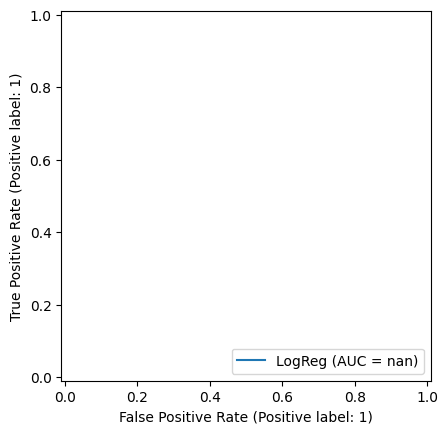

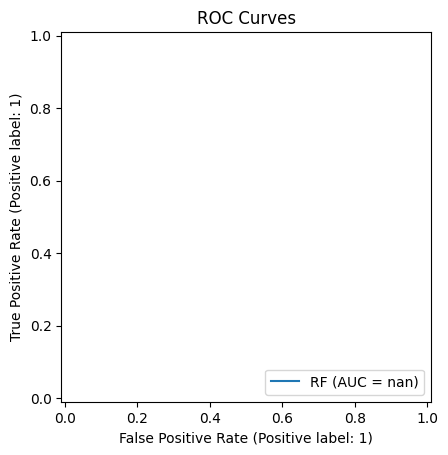

<Figure size 600x500 with 0 Axes>

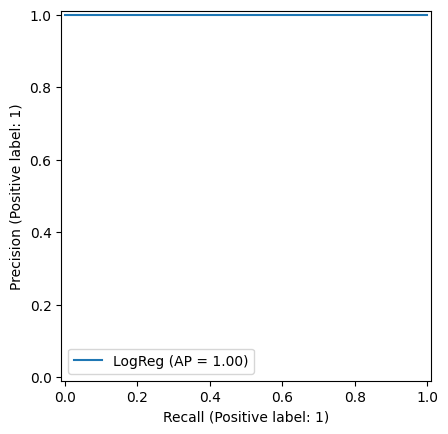

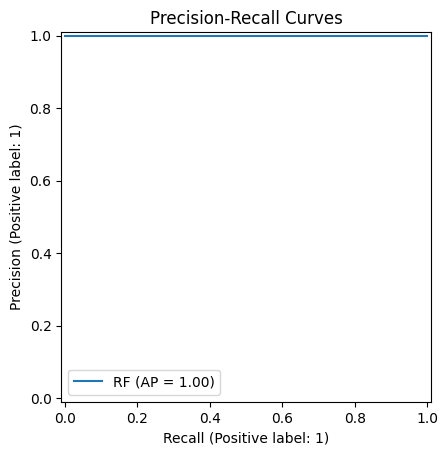

In [18]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, proba_lr, name="LogReg")
RocCurveDisplay.from_predictions(y_test, proba_rf, name="RF")
if proba_xgb is not None:
    RocCurveDisplay.from_predictions(y_test, proba_xgb, name="XGB")
plt.title("ROC Curves")
plt.show()

plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, proba_lr, name="LogReg")
PrecisionRecallDisplay.from_predictions(y_test, proba_rf, name="RF")
if proba_xgb is not None:
    PrecisionRecallDisplay.from_predictions(y_test, proba_xgb, name="XGB")
plt.title("Precision-Recall Curves")
plt.show()

---
## Étape 4 — Interprétation

### 4.1 Feature importances (Random Forest)

recency_days              0.425672
recency                   0.391380
tenure_days               0.069772
peak_ratio                0.043799
n_active_months           0.015599
n_distinct_products       0.014538
frequency                 0.011337
monetary                  0.008859
std_interpurchase         0.006812
avg_items_per_order       0.003891
avg_basket                0.002572
last_basket               0.002095
spending_trend            0.002047
last_over_avg_basket      0.001062
country_United Kingdom    0.000063
dtype: float64

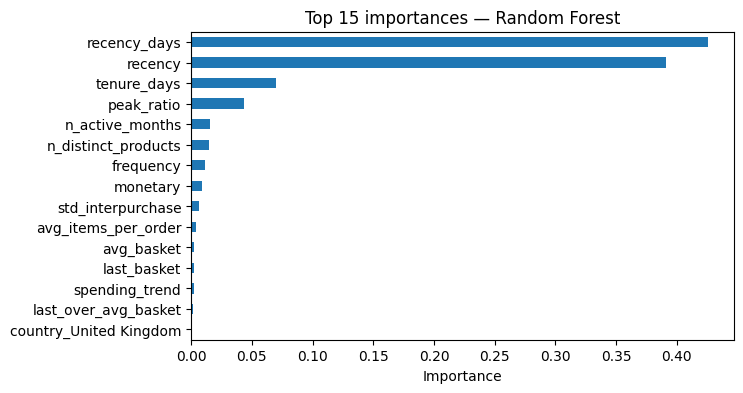

In [19]:
imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(imp_rf.head(15))

plt.figure(figsize=(7,4))
imp_rf.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 importances — Random Forest")
plt.xlabel("Importance")
plt.show()

### 4.2 Coefficients (Logistic Regression)

In [20]:
coef = logreg.named_steps["model"].coef_[0]
coef_s = pd.Series(coef, index=X_train.columns).sort_values(key=np.abs, ascending=False)
display(coef_s.head(15))

recency_days           14.164891
recency                14.164891
frequency               0.247297
n_active_months        -0.218559
country_Japan          -0.176117
tenure_days             0.172342
avg_basket             -0.167088
country_Iceland         0.140036
country_Poland          0.115745
country_Belgium        -0.104831
std_interpurchase      -0.104232
monetary                0.098552
country_Cyprus          0.098449
country_Netherlands     0.094219
country_Italy           0.078192
dtype: float64

---
## Étape 5 — Recommandations marketing

### 5.1 Scoring churn (ex: RF) + top clients à risque

In [21]:
data["churn_proba_rf"] = rf.predict_proba(data.drop(columns=["churn"]))[:,1]
top_risk = data.sort_values("churn_proba_rf", ascending=False).head(20)
top_risk[["recency","frequency","monetary","avg_basket","churn_proba_rf"]].head(20)

,recency,frequency,monetary,avg_basket,churn_proba_rf
customer_id,,,,,
12353.0,204,1,89.00,89.000000,1.0
63391.0,227,3,11.80,3.933333,1.0
63390.0,305,2,12.20,6.100000,1.0
63389.0,221,3,19.20,6.400000,1.0
63367.0,235,2,23.70,11.850000,1.0
34611.0,184,2,25.30,12.650000,1.0
34616.0,188,2,49.20,24.600000,1.0
34622.0,215,3,137.35,45.783333,1.0
34625.0,103,1,119.00,119.000000,1.0


### 5.2 Règle simple (exemple)

In [22]:
high_risk_rule = data[(data["recency_days"] > CHURN_THRESHOLD) & (data["spending_trend"] < 0)] if "recency_days" in data.columns else data[(data["recency"] > CHURN_THRESHOLD) & (data["spending_trend"] < 0)]
print("Nb clients règle 'high risk':", len(high_risk_rule))
high_risk_rule[["recency","frequency","monetary","spending_trend"]].head()

Nb clients règle 'high risk': 3787


,recency,frequency,monetary,spending_trend
customer_id,,,,
12363.0,110,2,552.00,-9.240000
12377.0,315,2,1628.12,-374.920000
12383.0,185,5,1850.56,-95.141786
12399.0,119,4,1108.65,-21.227714
12450.0,156,2,197.88,-5.880000


---
## Étape 6 — Conclusion (gabarit)

In [23]:
print(f"""Résumé (à copier en Markdown) :

- Seuil churn: {CHURN_THRESHOLD} jours (justifié par la distribution inter-achats).
- Features: RFM + tenure + diversité + régularité + tendance + saisonnalité.
- Modèles évalués: LogReg / RF / (XGB si dispo). 
- Analyse: commenter ROC-AUC et PR-AUC, puis présenter les top drivers et les actions.

Limites: définition churn dépend du seuil, classes potentiellement déséquilibrées, biais géographique.
""")

Résumé (à copier en Markdown) :

- Seuil churn: 90 jours (justifié par la distribution inter-achats).
- Features: RFM + tenure + diversité + régularité + tendance + saisonnalité.
- Modèles évalués: LogReg / RF / (XGB si dispo). 
- Analyse: commenter ROC-AUC et PR-AUC, puis présenter les top drivers et les actions.

Limites: définition churn dépend du seuil, classes potentiellement déséquilibrées, biais géographique.

